In [30]:
from langgraph.graph import StateGraph,START , END
from typing import TypedDict


In [61]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [62]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    balls = state['balls'];
    runs = state['runs'];

    sr = (runs/balls)*100;
    #state['sr'] = sr;

    return {"sr": sr}

In [63]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:

    balls = state['balls'];
    fours = state['fours'];
    sixes = state['sixes'];
    boundaries = fours + sixes

    bpb = balls/boundaries;

    if boundaries == 0:
        bpb = 0.0
    else:
        bpb = balls / boundaries
        
    return {"bpb": bpb}

In [64]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    runs = state['runs'];
    fours = state['fours'];
    sixes = state['sixes'];

    boundary_runs = (fours * 4) + (sixes * 6)

    if runs == 0:
        boundary_percentage = 0.0
    else:
        boundary_percentage = (boundary_runs / runs) * 100

    return {"boundary_percentage": boundary_percentage};

In [65]:
def create_summary(state: BatsmanState) -> BatsmanState:

    runs = state['runs']
    balls = state['balls']
    fours = state['fours']
    sixes = state['sixes']
    sr = state['sr']
    bpb = state['bpb']
    boundary_percentage = state['boundary_percentage']

    summary = (
        f"The batsman scored {runs} runs from {balls} balls, "
        f"with {fours} fours and {sixes} sixes. "
        f"The strike rate was {sr:.2f}, "
        f"with a boundary every {bpb:.2f} balls. "
        f"Boundaries contributed {boundary_percentage:.2f}% of the total runs."
    )

    #state['summary'] = summary

    return {"summary": summary}

In [66]:
#create graph
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)
graph.add_node('create_summary',create_summary)

#edges 
graph.add_edge(START,'calculate_sr');
graph.add_edge(START,'calculate_bpb');
graph.add_edge(START,'calculate_boundary_percentage');

graph.add_edge('calculate_sr','create_summary');
graph.add_edge('calculate_bpb','create_summary');
graph.add_edge('calculate_boundary_percentage','create_summary');

graph.add_edge('create_summary',END)

#compile 
workflow = graph.compile()


In [67]:
initial_state = {
    "runs": 80,
    "balls": 50,
    "fours": 8,
    "sixes": 3
}
final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 80, 'balls': 50, 'fours': 8, 'sixes': 3, 'sr': 160.0, 'bpb': 4.545454545454546, 'boundary_percentage': 62.5, 'summary': 'The batsman scored 80 runs from 50 balls, with 8 fours and 3 sixes. The strike rate was 160.00, with a boundary every 4.55 balls. Boundaries contributed 62.50% of the total runs.'}


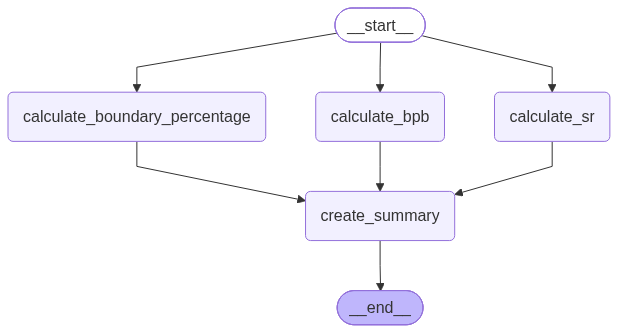

In [68]:
#view the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())